<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº1: Síntesis y operaciones de señales
#### Ivana Rocio Miranda



## Introducción

El presente trabajo aborda la **síntesis de señales en tiempo discreto**, tanto determinísticas
como aleatorias, y su análisis en el dominio de la frecuencia mediante la Transformada de Fourier.

### Conceptos fundamentales

**Señal sinusoidal discreta:**  
Una señal sinusoidal discreta se expresa como:

$$x[n] = A \cdot \sin(2\pi f_0 n T_s + \phi) + DC$$

donde $A$ es la amplitud, $f_0$ la frecuencia, $T_s = 1/f_s$ el período de muestreo, y $\phi$ la fase inicial.

**Energía y potencia:**  
- Una señal **periódica** de duración infinita (como una sinusoide o una señal cuadrada) tiene energía infinita pero **potencia media finita** → es una **señal de potencia**.
- Una señal de duración finita (como un pulso aislado) tiene energía finita → es una **señal de energía**.
- Para una sinusoide de amplitud $A$: $P = A^2/2$. Para una señal cuadrada simétrica de amplitud $A$: $P = A^2$.

**Teorema de Parseval:**  
Relaciona la energía/potencia calculada en el dominio temporal con la calculada a partir de su
Transformada de Fourier. Para la DFT de $N$ puntos:

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N}\sum_{k=0}^{N-1} |X[k]|^2$$

por lo que la potencia media puede obtenerse también como $P = \dfrac{1}{N^2}\sum_{k=0}^{N-1} |X[k]|^2$.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx

N = 1000      # muestras, fijo para todo el ejercicio
fs = 20000    # Hz, frecuencia de muestreo común para todas las señales
f0 = 2000     # Hz, frecuencia de la señal a sintetizar
df = fs / N   # resolución espectral
ff_fft = np.arange(N) * df
b = ff_fft <= fs/2   # media espectral (positiva) para graficar


---
## Ejercicio 1 – Síntesis de señales y análisis espectral

En todos los casos se usan $N = 1000$ muestras y $f_s = 20\,000$ Hz.


### Inciso 1 – Señal sinusoidal de 2 kHz

Se genera una sinusoide pura de $f_0 = 2000$ Hz, amplitud unitaria, sin offset y sin desfase.

- **Puntos por período:** $f_s/f_0 = 20000/2000 = 10$ muestras por período → cumple el mínimo pedido.
- **Duración de la ventana:** $N/f_s = 50$ ms → se observan $f_0 \cdot (N/f_s) = 100$ períodos completos.
- **Clasificación:** Señal de **potencia** (periódica → energía infinita, potencia media finita $P = A^2/2 = 0.5$ W).


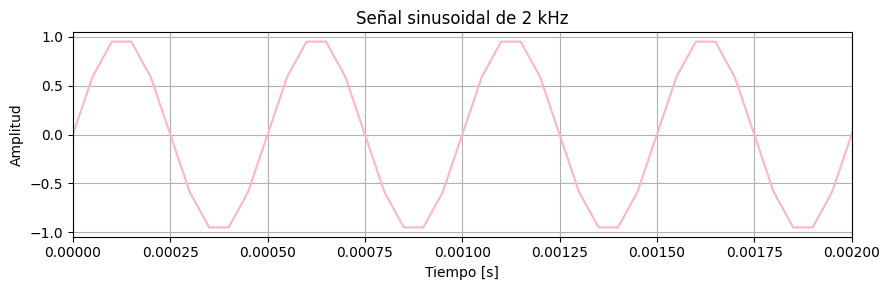

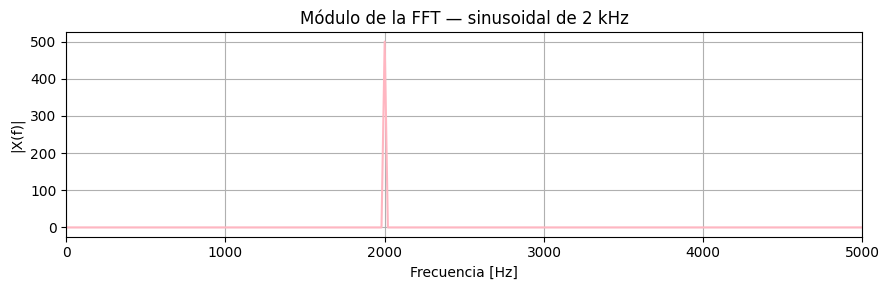

In [2]:
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

plt.figure(figsize=(9,3))
plt.plot(tt, xx, color='lightpink')
plt.xlim(0, 0.002)
plt.title("Señal sinusoidal de 2 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

XX = np.fft.fft(xx)
plt.figure(figsize=(9,3))
plt.plot(ff_fft[b], np.abs(XX)[b], color='lightpink')
plt.xlim(0, 5000)
plt.title("Módulo de la FFT — sinusoidal de 2 kHz")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.tight_layout()
plt.show()


### Inciso 2 – Misma señal con 2 W de potencia media y desfasada $\pi/2$

Para una sinusoide, $P = A^2/2$. Para lograr $P = 2\,\text{W}$ se necesita:

$$A = \sqrt{2 \cdot P} = \sqrt{2 \cdot 2} = 2$$

Se agrega además un desfase de $\phi = \pi/2$ (equivale a una cosinusoide).

- **Puntos por período y duración:** idénticos al inciso 1.
- **Clasificación:** Señal de **potencia** ($P = A^2/2 = 2$ W).


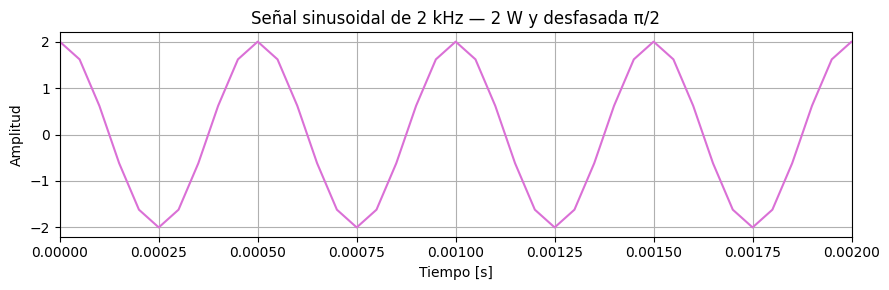

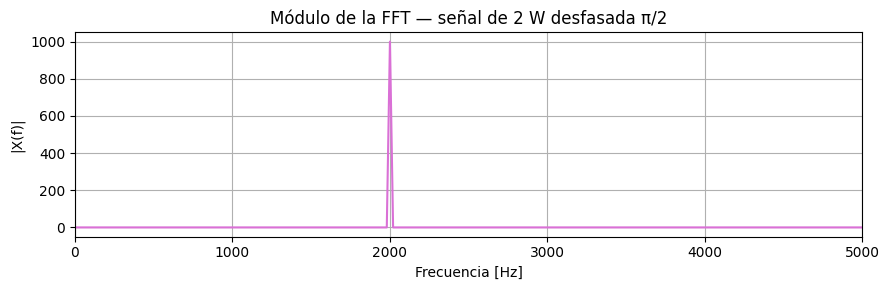

Potencia media medida en el tiempo: 2.000 W


In [3]:
A2 = np.sqrt(2 * 2)   # amplitud para P = 2 W
_, xx2 = mi_funcion_sen(vmax=A2, dc=0, ff=f0, ph=np.pi/2, nn=N, fs=fs)

plt.figure(figsize=(9,3))
plt.plot(tt, xx2, color='orchid')
plt.xlim(0, 0.002)
plt.title("Señal sinusoidal de 2 kHz — 2 W y desfasada π/2")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

XX2 = np.fft.fft(xx2)
plt.figure(figsize=(9,3))
plt.plot(ff_fft[b], np.abs(XX2)[b], color='orchid')
plt.xlim(0, 5000)
plt.title("Módulo de la FFT — señal de 2 W desfasada π/2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Potencia media medida en el tiempo: {np.mean(xx2**2):.3f} W")


### Inciso 3 – Ruido normalmente distribuido (DC = 0 V, varianza 0.1 W)

Para una distribución normal, la varianza $\sigma^2$ se fija directamente como parámetro de
`np.random.normal`, con $\sigma = \sqrt{0.1}$.

- **Clasificación:** Señal aleatoria; al tener duración finita en esta ventana se mide su potencia
  media como el valor cuadrático medio, que debería aproximarse a la varianza (0.1 W) ya que la media es 0 V.


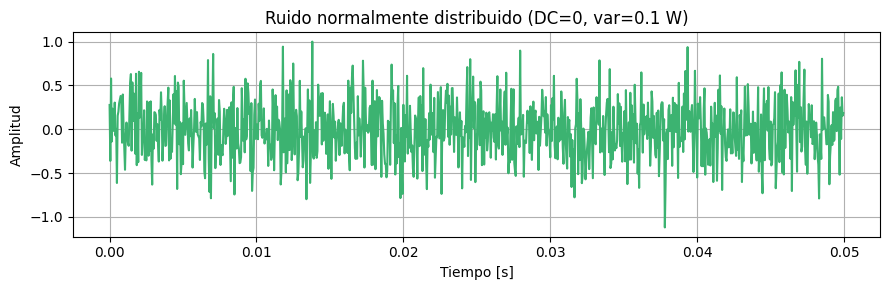

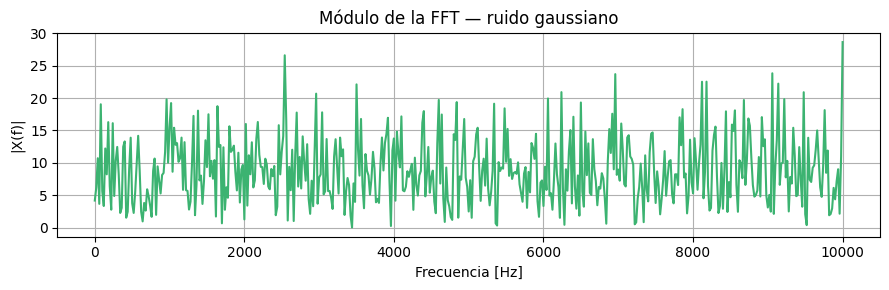

Media: -0.004 V | Varianza (potencia) medida: 0.104 W


In [4]:
dc = 0
var = 0.1
xx3 = np.random.normal(loc=dc, scale=np.sqrt(var), size=N)

plt.figure(figsize=(9,3))
plt.plot(tt, xx3, color='mediumseagreen')
plt.title("Ruido normalmente distribuido (DC=0, var=0.1 W)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

XX3 = np.fft.fft(xx3)
plt.figure(figsize=(9,3))
plt.plot(ff_fft[b], np.abs(XX3)[b], color='mediumseagreen')
plt.title("Módulo de la FFT — ruido gaussiano")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Media: {np.mean(xx3):.3f} V | Varianza (potencia) medida: {np.var(xx3):.3f} W")


### Inciso 4 – Ruido uniformemente distribuido (DC = 0 V, varianza 0.1 W)

Para una distribución uniforme en $[-a, a]$, la varianza es $\sigma^2 = a^2/3$, por lo tanto:

$$a = \sqrt{3 \cdot \sigma^2} = \sqrt{3 \cdot 0.1}$$


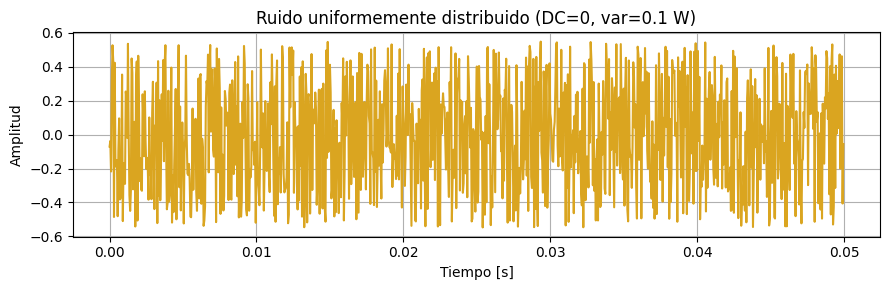

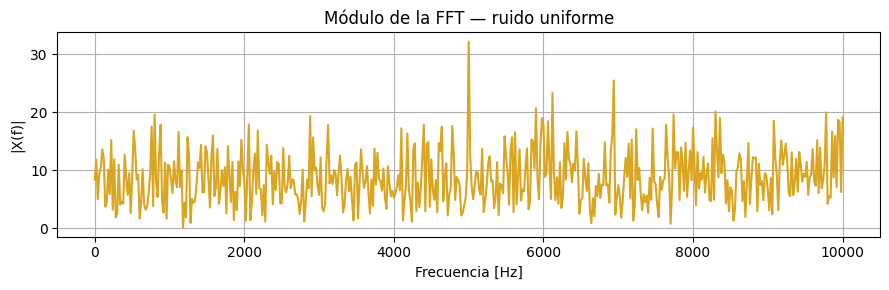

Media: -0.008 V | Varianza (potencia) medida: 0.098 W


In [5]:
a = np.sqrt(3 * var)
xx4 = np.random.uniform(low=-a, high=a, size=N)

plt.figure(figsize=(9,3))
plt.plot(tt, xx4, color='goldenrod')
plt.title("Ruido uniformemente distribuido (DC=0, var=0.1 W)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

XX4 = np.fft.fft(xx4)
plt.figure(figsize=(9,3))
plt.plot(ff_fft[b], np.abs(XX4)[b], color='goldenrod')
plt.title("Módulo de la FFT — ruido uniforme")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Media: {np.mean(xx4):.3f} V | Varianza (potencia) medida: {np.var(xx4):.3f} W")


### Inciso 5 – Pulso rectangular de 2 kHz, 1 W de potencia, ciclo de actividad 50%

Se utiliza `scipy.signal.square` con `duty=0.5`, que genera una señal periódica que alterna
entre $-1$ y $+1$ con el 50% del período en cada nivel. Para una señal de este tipo,
$P = A^2 = 1\,\text{W}$ con $A=1$, por lo que no hace falta escalarla.

- **Clasificación:** Señal de **potencia** (periódica, $P = A^2 = 1$ W).


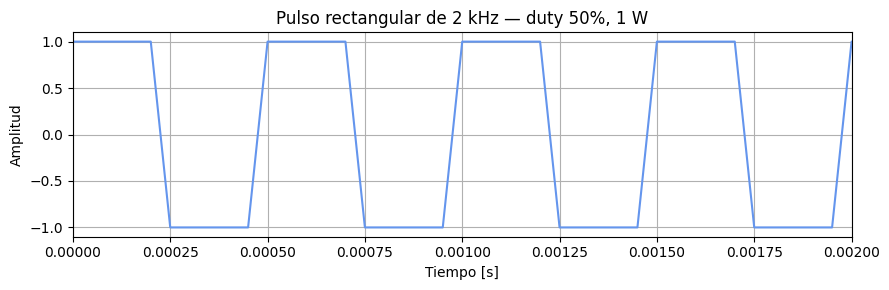

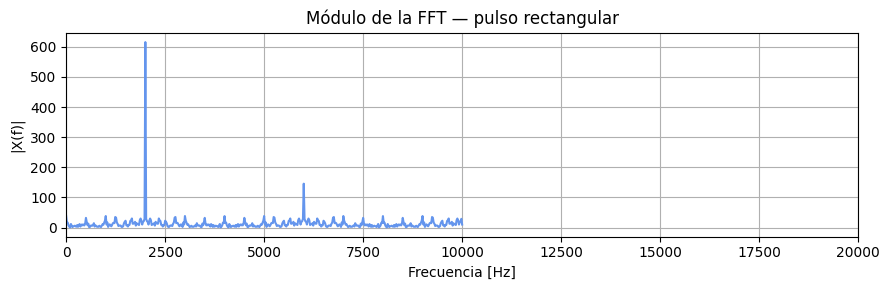

Potencia media medida en el tiempo: 1.000 W


In [6]:
xx5 = sig.square(2*np.pi*f0*tt, duty=0.5)

plt.figure(figsize=(9,3))
plt.plot(tt, xx5, color='cornflowerblue')
plt.xlim(0, 0.002)
plt.title("Pulso rectangular de 2 kHz — duty 50%, 1 W")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

XX5 = np.fft.fft(xx5)
plt.figure(figsize=(9,3))
plt.plot(ff_fft[b], np.abs(XX5)[b], color='cornflowerblue')
plt.xlim(0, 20000)
plt.title("Módulo de la FFT — pulso rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Potencia media medida en el tiempo: {np.mean(xx5**2):.3f} W")


---
## Bonus

### Otra señal de `scipy.signal`: diente de sierra

Se sintetiza una señal diente de sierra (`sig.sawtooth`) de la misma frecuencia, disponible
en el mismo apartado *Waveforms* de scipy.


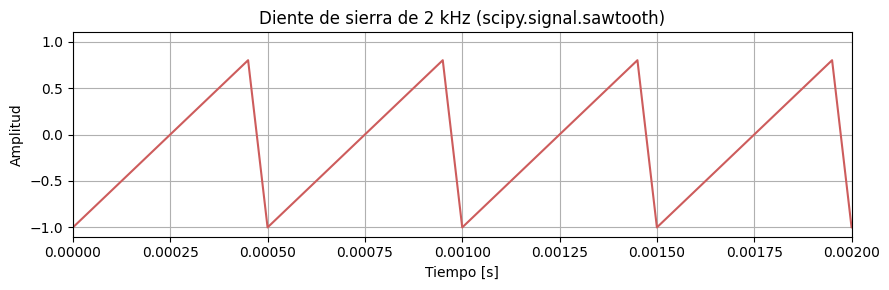

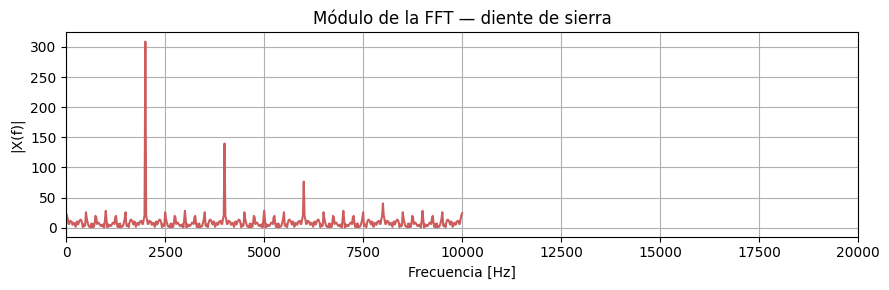

In [7]:
xx6 = sig.sawtooth(2*np.pi*f0*tt)

plt.figure(figsize=(9,3))
plt.plot(tt, xx6, color='indianred')
plt.xlim(0, 0.002)
plt.title("Diente de sierra de 2 kHz (scipy.signal.sawtooth)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

XX6 = np.fft.fft(xx6)
plt.figure(figsize=(9,3))
plt.plot(ff_fft[b], np.abs(XX6)[b], color='indianred')
plt.xlim(0, 20000)
plt.title("Módulo de la FFT — diente de sierra")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.tight_layout()
plt.show()


### Medición de potencia mediante la Transformada de Fourier (Parseval)

Según Parseval, la potencia media de una señal puede calcularse tanto en el tiempo como a
partir de su espectro:

$$P = \frac{1}{N}\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N^2}\sum_{k=0}^{N-1} |X[k]|^2$$

Se verifica esta igualdad para cada una de las señales sintetizadas.


In [8]:
def potencia_tiempo(x):
    return np.mean(np.abs(x)**2)

def potencia_frecuencia(x):
    X = np.fft.fft(x)
    return np.sum(np.abs(X)**2) / len(x)**2

senales = {
    "Sinusoidal 2kHz (0.5 W)": xx,
    "Sinusoidal 2 W, π/2":     xx2,
    "Ruido gaussiano (0.1 W)": xx3,
    "Ruido uniforme (0.1 W)":  xx4,
    "Pulso rectangular (1 W)": xx5,
    "Diente de sierra":        xx6,
}

for nombre, x in senales.items():
    Pt = potencia_tiempo(x)
    Pf = potencia_frecuencia(x)
    print(f"{nombre:28s} | P (tiempo) = {Pt:.4f} W | P (Parseval) = {Pf:.4f} W")


Sinusoidal 2kHz (0.5 W)      | P (tiempo) = 0.5000 W | P (Parseval) = 0.5000 W
Sinusoidal 2 W, π/2          | P (tiempo) = 2.0000 W | P (Parseval) = 2.0000 W
Ruido gaussiano (0.1 W)      | P (tiempo) = 0.1038 W | P (Parseval) = 0.1038 W
Ruido uniforme (0.1 W)       | P (tiempo) = 0.0983 W | P (Parseval) = 0.0983 W
Pulso rectangular (1 W)      | P (tiempo) = 1.0000 W | P (Parseval) = 1.0000 W
Diente de sierra             | P (tiempo) = 0.3400 W | P (Parseval) = 0.3400 W


## Ejercicio 2 – Sistema LTI: convolución con h[n] = δ[n] − δ[n−4]

Se analiza un sistema LTI cuya respuesta al impulso es:

$$h[n] = \delta[n] - \delta[n-4]$$

Este sistema **resta a cada muestra el valor que tenía 4 instantes antes**, funcionando como un **filtro paso-altos** o diferenciador con retardo. Señales constantes (DC) se cancelan completamente; señales que varían rápidamente producen una salida de alta amplitud.

### Respuesta al impulso h[n]

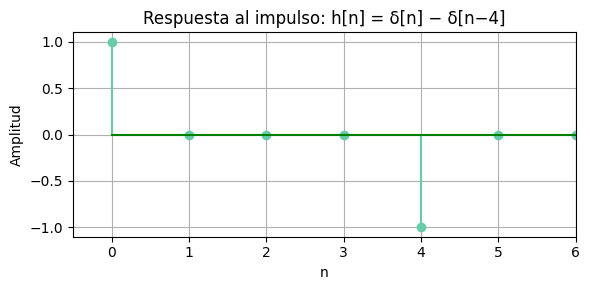

In [9]:
N = 100
n = np.arange(0, N)
h = np.zeros(N)
h[n == 0] = 1
h[n == 4] = -1

plt.figure(figsize=(6,3))
plt.stem(n, h, linefmt='mediumaquamarine', basefmt='green')
plt.title("Respuesta al impulso: h[n] = δ[n] − δ[n−4]")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.xlim(-0.5, 6)
plt.grid()
plt.tight_layout()
plt.show()

### Inciso a – Entrada: cosinusoide discreta $x[n] = \cos(2\pi f_0 n T_s)$

Con $f_0 = 1$ Hz y $f_s = 10$ Hz, la señal de entrada es una cosinusoide de período $T = 1/f_0 = 1$ s, es decir **10 muestras por período**.

**Fenómeno observable:** El sistema aplica la diferencia $x[n] - x[n-4]$. Para una cosinusoide, esto equivale a filtrar según la respuesta en frecuencia del sistema. Como el período es de 10 muestras y el retardo es de 4 muestras ($4/10 = 144°$), la salida es otra sinusoide **de la misma frecuencia** pero con amplitud y fase modificadas:

$$y[n] = \cos(2\pi f_0 n T_s) - \cos(2\pi f_0 (n-4) T_s)$$

Se conserva la periodicidad y la forma sinusoidal — solo cambia la amplitud y la fase.

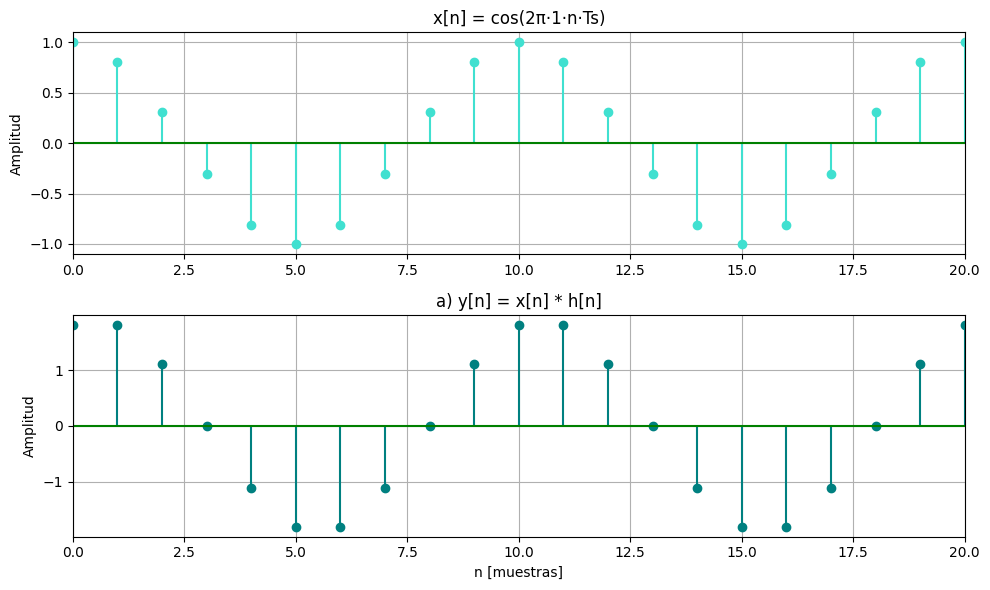

In [10]:
fs_ej2 = 10
ts_ej2 = 1/fs_ej2
f0 = 1
x = np.cos(2*np.pi*f0*n*ts_ej2)
y_a = sig.convolve(x, h, mode='same')

fig, axes = plt.subplots(2, 1, figsize=(10,6))

axes[0].stem(n, x, linefmt='turquoise', basefmt='green')
axes[0].set_xlim(0, 20)
axes[0].set_title("x[n] = cos(2π·1·n·Ts)")
axes[0].set_ylabel("Amplitud")
axes[0].grid()

axes[1].stem(n, y_a, linefmt='teal', markerfmt='o', basefmt='green')
axes[1].set_xlim(0, 20)
axes[1].set_title("a) y[n] = x[n] * h[n]")
axes[1].set_xlabel("n [muestras]")
axes[1].set_ylabel("Amplitud")
axes[1].grid()

plt.tight_layout()
plt.show()

### Inciso b – Entrada: exponencial decreciente $x[n] = (1/2)^n \cdot u[n]$

La entrada es una **exponencial real causal** con base $0.5 < 1$, por lo que decae hacia cero a medida que $n$ aumenta. Es una señal de **energía** (la suma de sus cuadrados converge).

**Fenómeno observable:** La salida $y[n] = x[n] - x[n-4] = (1/2)^n - (1/2)^{n-4}$ también decae exponencialmente, pero con una **amplitud inicial más pronunciada** y luego se extingue más rápido que la entrada. El sistema resalta el transitorio inicial (donde la variación entre muestras es mayor) y atenúa la cola donde la señal ya casi no cambia.

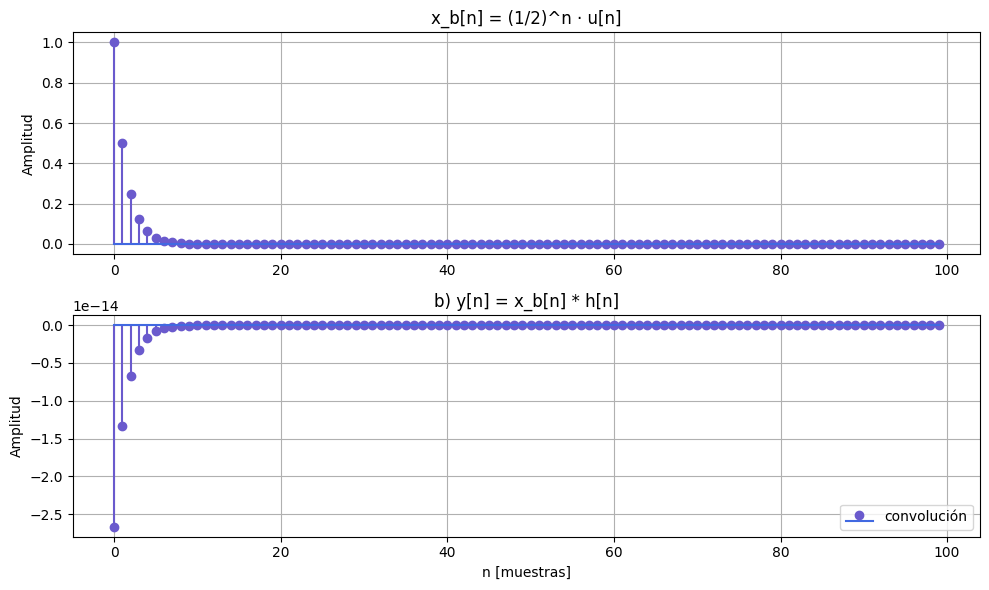

In [11]:
xb = (0.5)**n * (n >= 0)
yb = sig.convolve(xb, h, mode='same')

fig, axes = plt.subplots(2, 1, figsize=(10,6))

axes[0].stem(n, xb, linefmt='slateblue', basefmt='royalblue')
axes[0].set_title("x_b[n] = (1/2)^n · u[n]")
axes[0].set_ylabel("Amplitud")
axes[0].grid()

axes[1].stem(n, yb, linefmt='slateblue', basefmt='royalblue', label='convolución')
axes[1].set_title("b) y[n] = x_b[n] * h[n]")
axes[1].set_xlabel("n [muestras]")
axes[1].set_ylabel("Amplitud")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

### Inciso c – Entrada: pulso discreto $x_c[n] = u[n+1] - u[n-2]$

La entrada es un **pulso rectangular discreto** que vale 1 en el rango $n \in \{-1, 0, 1\}$ (3 muestras activas) y cero en el resto. Es una señal de **energía** (soporte finito, energía $E = 3$).

**Fenómeno observable:** Al convolver un pulso con $h[n] = \delta[n] - \delta[n-4]$, el sistema produce **dos réplicas del pulso**: una positiva en la posición original y otra negativa desplazada 4 muestras. Donde se solapan, las contribuciones se suman algebraicamente. La salida tiene soporte finito (señal de **energía**), al igual que la entrada.

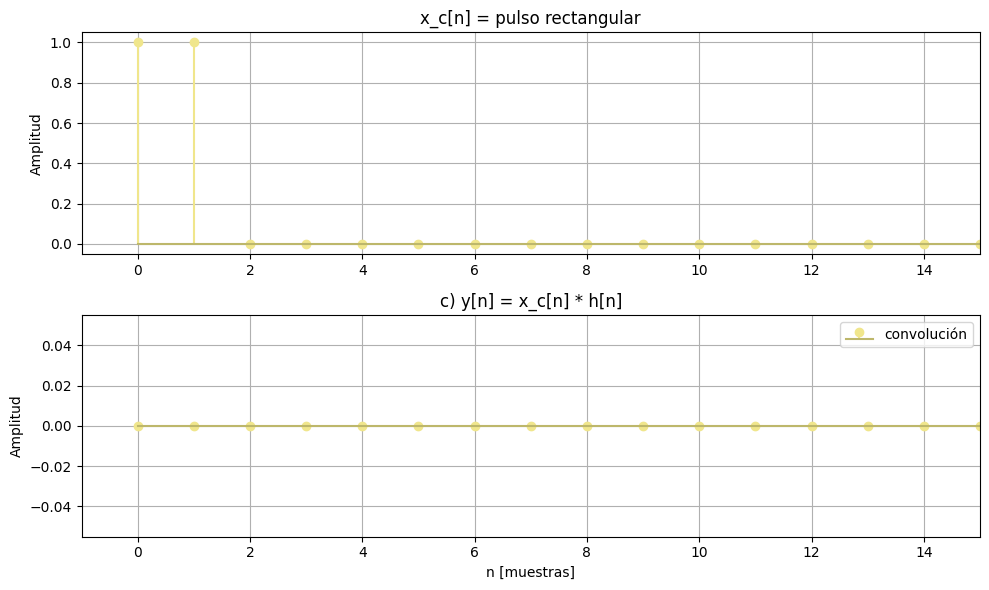

In [12]:
xc = (n >= -1).astype(int) - (n >= 2).astype(int)  # pulso en n = -1, 0, 1 (pero n empieza en 0 → n = 0, 1)
yc = sig.convolve(xc, h, mode='same')

fig, axes = plt.subplots(2, 1, figsize=(10,6))

axes[0].stem(n, xc, linefmt='khaki', basefmt='darkkhaki')
axes[0].set_title("x_c[n] = pulso rectangular")
axes[0].set_ylabel("Amplitud")
axes[0].set_xlim(-1, 15)
axes[0].grid()

axes[1].stem(n, yc, linefmt='khaki', basefmt='darkkhaki', label='convolución')
axes[1].set_title("c) y[n] = x_c[n] * h[n]")
axes[1].set_xlabel("n [muestras]")
axes[1].set_ylabel("Amplitud")
axes[1].set_xlim(-1, 15)
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

---
## Conclusiones

- Las señales periódicas (sinusoidal, pulso rectangular, diente de sierra) son **señales de
  potencia** ya que tienen energía infinita pero potencia media finita y no nula.
- Las secuencias de ruido (gaussiano y uniforme) fueron generadas con media 0 V y varianza
  0.1 W; al medir la varianza muestral sobre las $N=1000$ muestras se obtiene un valor cercano
  al teórico, con la dispersión propia de trabajar con una realización finita del proceso aleatorio.
- El teorema de Parseval permite calcular la potencia media de una señal directamente a partir
  del módulo de su Transformada de Fourier, sin necesidad de operar en el dominio temporal,
  y los resultados obtenidos coinciden (a menos de errores numéricos) con los calculados
  directamente sobre las muestras.
- El sistema LTI $h[n] = \delta[n] - \delta[n-4]$ actúa como **filtro diferenciador**: atenúa componentes constantes y realza cambios rápidos, con efectos distintos según el tipo de señal de entrada (sinusoide, exponencial o pulso).
